In [ ]:
import os
print(os.listdir('/content'))

['.config', 'archive (4).zip', 'sample_data']


In [ ]:
from zipfile import ZipFile

zip_path = "/content/archive (4).zip"

with ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall("/content/dataset")

print("Dataset extracted successfully!")

Dataset extracted successfully!


In [ ]:
import os
print(os.listdir('/content/dataset'))

['train', 'test']


In [ ]:
import os
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import cv2

from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout
from tensorflow.keras.optimizers import Adam

In [ ]:
train_path = "/content/dataset/train"
test_path = "/content/dataset/test"

print("Train Classes:", os.listdir(train_path))
print("Test Classes:", os.listdir(test_path))

Train Classes: ['sad', 'angry', 'neutral', 'happy']
Test Classes: ['sad', 'angry', 'neutral', 'happy']


In [ ]:
for category in os.listdir(train_path):
    category_path = os.path.join(train_path, category)
    print(category, len(os.listdir(category_path)))

sad 4830
angry 3995
neutral 4965
happy 7215


In [ ]:
for category in os.listdir(test_path):
    category_path = os.path.join(test_path, category)
    print(category, len(os.listdir(category_path)))

sad 1247
angry 958
neutral 1233
happy 1774


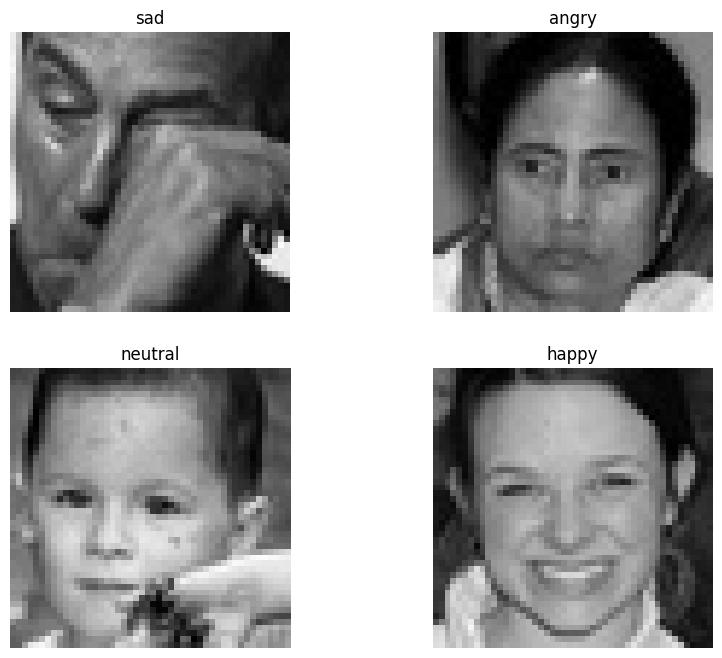

In [ ]:
plt.figure(figsize=(10,8))

classes = os.listdir(train_path)

for i, category in enumerate(classes):
    img_name = os.listdir(os.path.join(train_path, category))[0]
    img_path = os.path.join(train_path, category, img_name)

    img = cv2.imread(img_path)
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

    plt.subplot(2,2,i+1)
    plt.imshow(img)
    plt.title(category)
    plt.axis("off")

plt.show()

In [ ]:
train_datagen = ImageDataGenerator(
    rescale=1./255,
    validation_split=0.2,

    rotation_range=20,
    width_shift_range=0.2,
    height_shift_range=0.2,
    zoom_range=0.2,
    horizontal_flip=True
)

In [ ]:
test_datagen = ImageDataGenerator(
    rescale=1./255
)

In [ ]:
train_generator = train_datagen.flow_from_directory(
    train_path,
    target_size=(48,48),
    batch_size=64,
    color_mode='grayscale',
    class_mode='categorical',
    subset='training'
)

Found 16804 images belonging to 4 classes.


In [ ]:
validation_generator = train_datagen.flow_from_directory(
    train_path,
    target_size=(48,48),
    batch_size=64,
    color_mode='grayscale',
    class_mode='categorical',
    subset='validation'
)

Found 4201 images belonging to 4 classes.


In [ ]:
test_generator = test_datagen.flow_from_directory(
    test_path,
    target_size=(48,48),
    batch_size=64,
    color_mode='grayscale',
    class_mode='categorical',
    shuffle=False
)

Found 5212 images belonging to 4 classes.


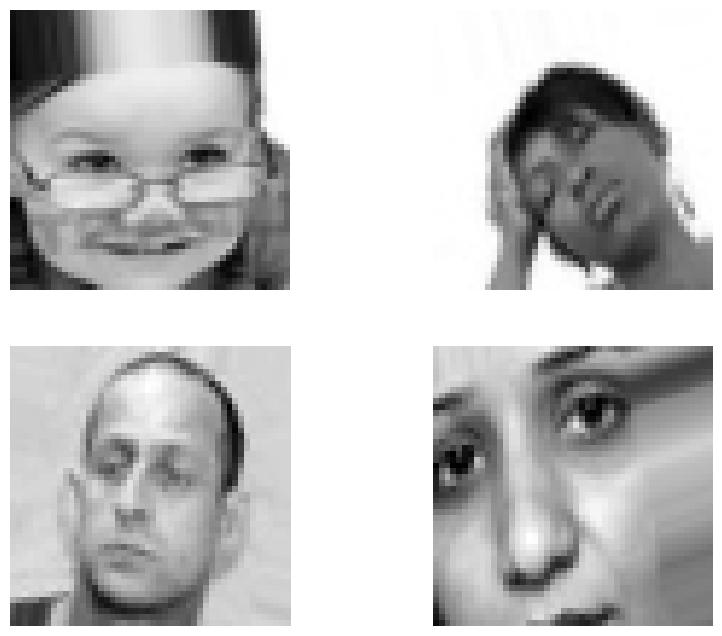

In [ ]:
images, labels = next(train_generator)

plt.figure(figsize=(10,8))

for i in range(4):
    plt.subplot(2,2,i+1)
    plt.imshow(images[i].reshape(48,48), cmap='gray')
    plt.axis('off')

plt.show()

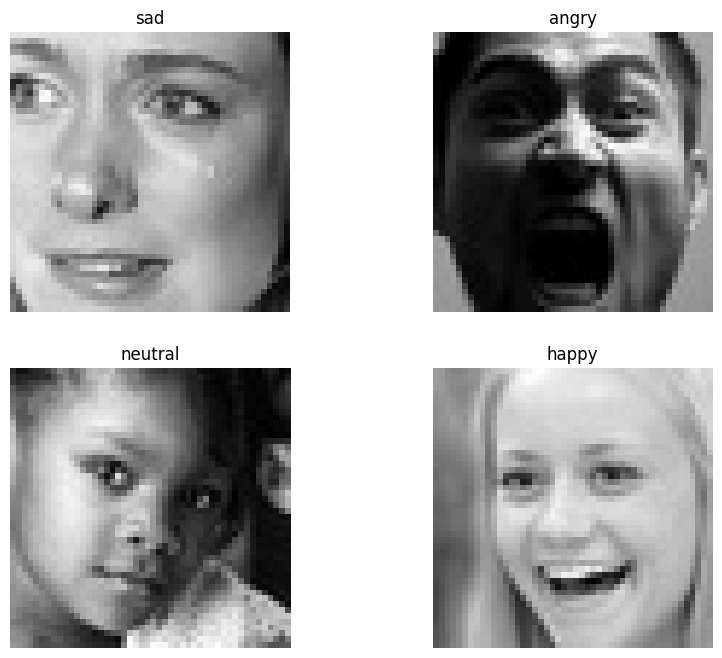

In [ ]:
import matplotlib.pyplot as plt
import cv2
import os

classes = os.listdir(train_path)

plt.figure(figsize=(10,8))

for i, category in enumerate(classes):
    img_name = os.listdir(os.path.join(train_path, category))[5]
    img_path = os.path.join(train_path, category, img_name)

    img = cv2.imread(img_path, cv2.IMREAD_GRAYSCALE)

    plt.subplot(2,2,i+1)
    plt.imshow(img, cmap='gray')
    plt.title(category)
    plt.axis('off')

plt.show()

In [ ]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout, BatchNormalization

model = Sequential()

# Layer 1
model.add(Conv2D(32, (3,3), activation='relu', input_shape=(48,48,1)))
model.add(BatchNormalization())
model.add(MaxPooling2D(pool_size=(2,2)))
model.add(Dropout(0.25))

# Layer 2
model.add(Conv2D(64, (3,3), activation='relu'))
model.add(BatchNormalization())
model.add(MaxPooling2D(pool_size=(2,2)))
model.add(Dropout(0.25))

# Layer 3
model.add(Conv2D(128, (3,3), activation='relu'))
model.add(BatchNormalization())
model.add(MaxPooling2D(pool_size=(2,2)))
model.add(Dropout(0.25))

# Flatten
model.add(Flatten())

# Dense layers
model.add(Dense(256, activation='relu'))
model.add(Dropout(0.5))

# Output layer
model.add(Dense(4, activation='softmax'))

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [ ]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 46, 46, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 46, 46, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 23, 23, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 23, 23, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 21, 21, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 21, 21, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 10, 10, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 10, 10, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 8, 8, 128)      │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 8, 8, 128)      │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 4, 4, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 4, 4, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 2048)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │       524,544 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 4)              │         1,028 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 619,140 (2.36 MB)

 Trainable params: 618,692 (2.36 MB)

 Non-trainable params: 448 (1.75 KB)

In [ ]:
from tensorflow.keras.optimizers import Adam

model.compile(
    optimizer=Adam(learning_rate=0.001),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

In [ ]:
from tensorflow.keras.callbacks import EarlyStopping

early_stop = EarlyStopping(
    monitor='val_loss',
    patience=5,
    restore_best_weights=True
)

In [ ]:
history = model.fit(
    train_generator,
    validation_data=validation_generator,
    epochs=30,
    callbacks=[early_stop]
)

Epoch 1/30
263/263 ━━━━━━━━━━━━━━━━━━━━ 107s 394ms/step - accuracy: 0.3167 - loss: 1.5008 - val_accuracy: 0.3461 - val_loss: 2.0215
Epoch 2/30
263/263 ━━━━━━━━━━━━━━━━━━━━ 101s 384ms/step - accuracy: 0.3425 - loss: 1.3599 - val_accuracy: 0.3344 - val_loss: 1.4031
Epoch 3/30
263/263 ━━━━━━━━━━━━━━━━━━━━ 103s 392ms/step - accuracy: 0.3436 - loss: 1.3527 - val_accuracy: 0.3371 - val_loss: 1.3646
Epoch 4/30
263/263 ━━━━━━━━━━━━━━━━━━━━ 102s 386ms/step - accuracy: 0.3409 - loss: 1.3530 - val_accuracy: 0.3463 - val_loss: 1.3789
Epoch 5/30
263/263 ━━━━━━━━━━━━━━━━━━━━ 103s 392ms/step - accuracy: 0.3490 - loss: 1.3393 - val_accuracy: 0.3494 - val_loss: 1.4294
Epoch 6/30
263/263 ━━━━━━━━━━━━━━━━━━━━ 103s 391ms/step - accuracy: 0.3528 - loss: 1.3308 - val_accuracy: 0.3552 - val_loss: 1.3334
Epoch 7/30
263/263 ━━━━━━━━━━━━━━━━━━━━ 103s 390ms/step - accuracy: 0.3595 - loss: 1.3179 - val_accuracy: 0.3766 - val_loss: 1.3393
Epoch 8/30
263/263 ━━━━━━━━━━━━━━━━━━━━ 145s 403ms/step - accuracy: 0.3794 -

In [ ]:
test_loss, test_accuracy = model.evaluate(test_generator)

print("Test Accuracy:", test_accuracy)

82/82 ━━━━━━━━━━━━━━━━━━━━ 6s 74ms/step - accuracy: 0.6050 - loss: 0.9272
Test Accuracy: 0.6049501299858093


In [ ]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator

train_datagen_tl = ImageDataGenerator(
    rescale=1./255,
    validation_split=0.2,
    rotation_range=10,
    width_shift_range=0.1,
    height_shift_range=0.1,
    zoom_range=0.1,
    horizontal_flip=True
)

test_datagen_tl = ImageDataGenerator(rescale=1./255)

In [ ]:
train_generator_tl = train_datagen_tl.flow_from_directory(
    train_path,
    target_size=(224,224),
    batch_size=32,
    class_mode='categorical',
    subset='training'
)

Found 16804 images belonging to 4 classes.


In [ ]:
validation_generator_tl = train_datagen_tl.flow_from_directory(
    train_path,
    target_size=(224,224),
    batch_size=32,
    class_mode='categorical',
    subset='validation'
)

Found 4201 images belonging to 4 classes.


In [ ]:
test_generator_tl = test_datagen_tl.flow_from_directory(
    test_path,
    target_size=(224,224),
    batch_size=32,
    class_mode='categorical',
    shuffle=False
)

Found 5212 images belonging to 4 classes.


In [ ]:
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import GlobalAveragePooling2D, Dense, Dropout
from tensorflow.keras.optimizers import Adam

In [ ]:
base_model = MobileNetV2(
    weights='imagenet',
    include_top=False,
    input_shape=(224,224,3)
)

base_model.trainable = False

9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


In [ ]:
model_tl = Sequential([
    base_model,
    GlobalAveragePooling2D(),
    Dense(128, activation='relu'),
    Dropout(0.5),
    Dense(4, activation='softmax')
])

In [ ]:
model_tl.compile(
    optimizer=Adam(learning_rate=0.0001),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

In [ ]:
history_tl = model_tl.fit(
    train_generator_tl,
    validation_data=validation_generator_tl,
    epochs=5
)

Epoch 1/5
526/526 ━━━━━━━━━━━━━━━━━━━━ 1135s 2s/step - accuracy: 0.4683 - loss: 1.2098 - val_accuracy: 0.4996 - val_loss: 1.1724
Epoch 2/5
526/526 ━━━━━━━━━━━━━━━━━━━━ 1112s 2s/step - accuracy: 0.4827 - loss: 1.1840 - val_accuracy: 0.5018 - val_loss: 1.1583
Epoch 3/5
526/526 ━━━━━━━━━━━━━━━━━━━━ 1115s 2s/step - accuracy: 0.4916 - loss: 1.1723 - val_accuracy: 0.4992 - val_loss: 1.1523
Epoch 4/5
526/526 ━━━━━━━━━━━━━━━━━━━━ 1116s 2s/step - accuracy: 0.4988 - loss: 1.1573 - val_accuracy: 0.5127 - val_loss: 1.1278
Epoch 5/5
526/526 ━━━━━━━━━━━━━━━━━━━━ 1121s 2s/step - accuracy: 0.5080 - loss: 1.1426 - val_accuracy: 0.5170 - val_loss: 1.1173


In [ ]:
test_loss_tl, test_acc_tl = model_tl.evaluate(test_generator_tl)

print("MobileNet Test Accuracy:", test_acc_tl)

163/163 ━━━━━━━━━━━━━━━━━━━━ 228s 1s/step - accuracy: 0.5313 - loss: 1.0975
MobileNet Test Accuracy: 0.5312739610671997


In [ ]:
import pandas as pd

comparison = pd.DataFrame({
    'Model': ['CNN', 'MobileNetV2'],
    'Accuracy': [60.49, 53.13]
})

print(comparison)

         Model  Accuracy
0          CNN     60.49
1  MobileNetV2     53.13


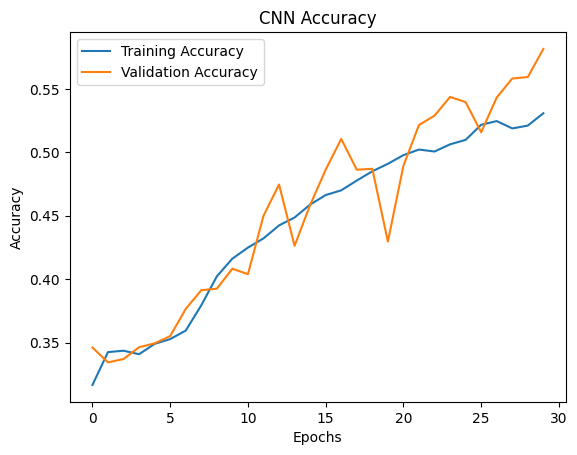

In [ ]:
import matplotlib.pyplot as plt

plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')

plt.title("CNN Accuracy")
plt.xlabel("Epochs")
plt.ylabel("Accuracy")
plt.legend()
plt.show()

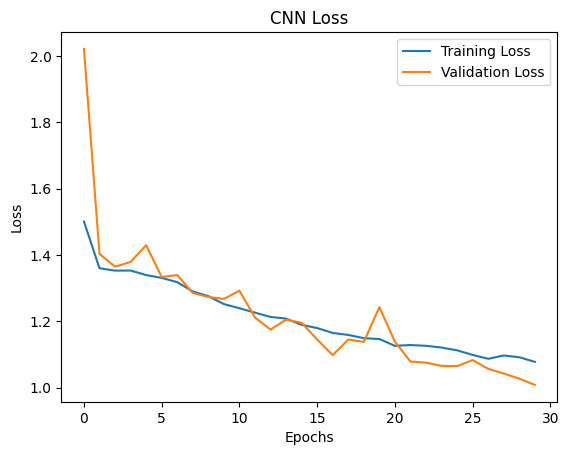

In [ ]:
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')

plt.title("CNN Loss")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.legend()
plt.show()

In [ ]:
import numpy as np
from sklearn.metrics import confusion_matrix
import seaborn as sns

predictions = model.predict(test_generator)
y_pred = np.argmax(predictions, axis=1)
y_true = test_generator.classes

82/82 ━━━━━━━━━━━━━━━━━━━━ 7s 88ms/step


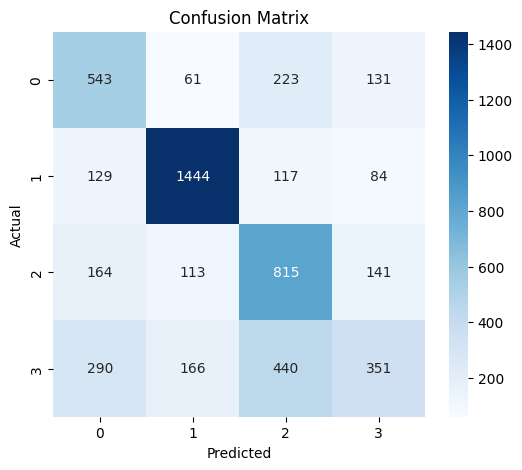

In [ ]:
cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

In [ ]:
from sklearn.metrics import classification_report

class_names = list(test_generator.class_indices.keys())

print(classification_report(y_true, y_pred, target_names=class_names))

              precision    recall  f1-score   support

       angry       0.48      0.57      0.52       958
       happy       0.81      0.81      0.81      1774
     neutral       0.51      0.66      0.58      1233
         sad       0.50      0.28      0.36      1247

    accuracy                           0.60      5212
   macro avg       0.57      0.58      0.57      5212
weighted avg       0.60      0.60      0.59      5212



In [ ]:
model.save("emotion_model.keras")
model_tl.save("mobilenet_model.keras")

In [ ]:
from google.colab import files

files.download("emotion_model.keras")
files.download("mobilenet_model.keras")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
model.save("emotion_model.h5")


In [ ]:
files.download("emotion_model.h5")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
model_tl.save("mobilenet_model.h5")

In [ ]:
files.download("mobilenet_model.h5")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
# cd "C:\Users\Shahd\OneDrive - AlRyada University for Science and Technology\Desktop\Sha77"
# streamlit run app.py